In [9]:
# Step 1: Install the dataset loader
!pip install ucimlrepo

In [10]:
# Step 2: Load data and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Load the AIDS Clinical Trials dataset
aids = fetch_ucirepo(id=890)
df = aids.data.features
df['cid'] = aids.data.targets  # survival/censoring indicator

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")

Dataset loaded successfully!
Shape: (2139, 24)

Columns:
['time', 'trt', 'age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'zprior', 'preanti', 'race', 'gender', 'str2', 'strat', 'symptom', 'treat', 'offtrt', 'cd40', 'cd420', 'cd80', 'cd820', 'cid']


/tmp/ipykernel_19607/746583611.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cid'] = aids.data.targets  # survival/censoring indicator


In [11]:
# Step 3: Fix the warning and do a quick data check
df = aids.data.features.copy()
df['cid'] = aids.data.targets.values

# Quick sanity check
print("Missing values:")
print(df.isnull().sum())
print(f"\nTreatment arms: {sorted(df['trt'].unique())}")
print(f"CD4 at baseline (mean): {df['cd40'].mean():.1f} cells/mm³")
print(f"CD4 at 20 weeks (mean): {df['cd420'].mean():.1f} cells/mm³")

Missing values:
time       0
trt        0
age        0
wtkg       0
hemo       0
homo       0
drugs      0
karnof     0
oprior     0
z30        0
zprior     0
preanti    0
race       0
gender     0
str2       0
strat      0
symptom    0
treat      0
offtrt     0
cd40       0
cd420      0
cd80       0
cd820      0
cid        0
dtype: int64

Treatment arms: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
CD4 at baseline (mean): 350.5 cells/mm³
CD4 at 20 weeks (mean): 371.3 cells/mm³


In [12]:
# Step 4: Create the binary target variable
df['cd4_improved'] = (df['cd420'] > df['cd40']).astype(int)

print(f"Patients who improved: {df['cd4_improved'].sum()} ({df['cd4_improved'].mean():.1%})")
print(f"Patients who didn't:   {(df['cd4_improved'] == 0).sum()} ({(df['cd4_improved'] == 0).mean():.1%})")

Patients who improved: 1176 (55.0%)
Patients who didn't:   963 (45.0%)


In [13]:
# Step 5: Train the Random Forest model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

feature_cols = ['cd40', 'cd80', 'trt', 'age', 'wtkg', 'karnof',
                'preanti', 'race', 'gender', 'homo', 'drugs',
                'oprior', 'z30', 'zprior', 'str2', 'strat', 'symptom']

X = df[feature_cols]
y = df['cd4_improved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_auc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc').mean()
gb_auc = cross_val_score(gb, X, y, cv=cv, scoring='roc_auc').mean()

print(f"Random Forest  CV AUC: {rf_auc:.4f}")
print(f"Gradient Boost CV AUC: {gb_auc:.4f}")

Random Forest  CV AUC: 0.6571
Gradient Boost CV AUC: 0.6513


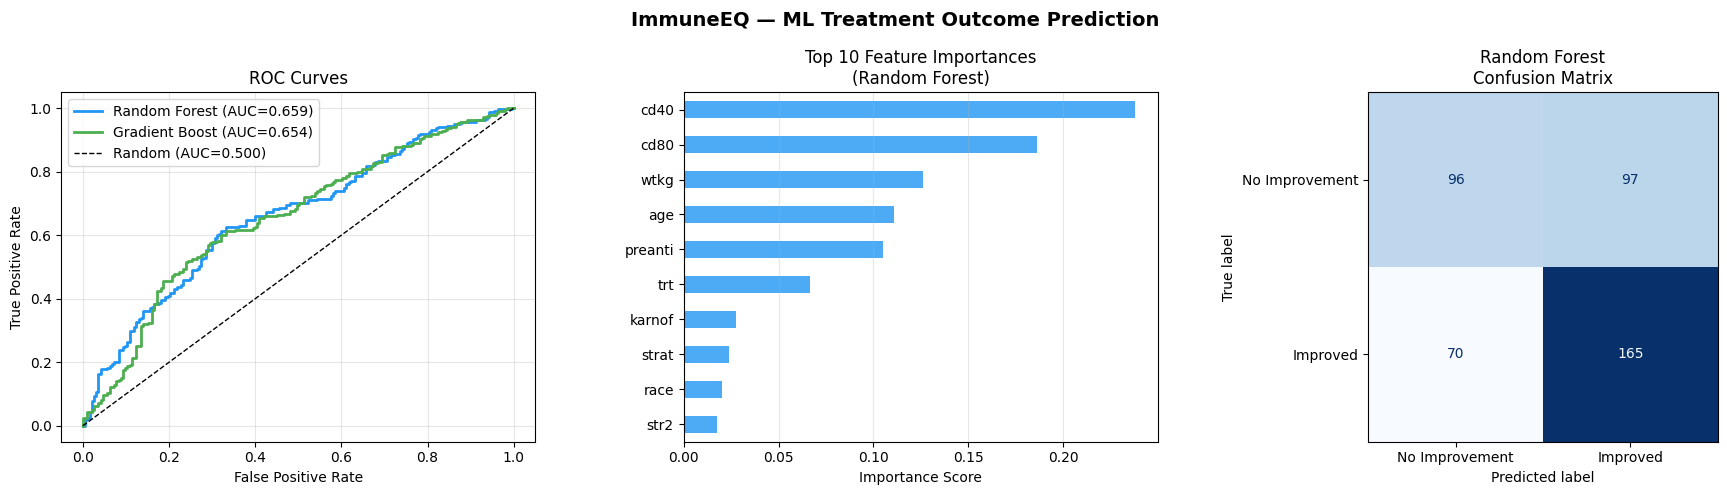

Saved!


In [14]:
# Step 6: Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ImmuneEQ — ML Treatment Outcome Prediction', fontsize=14, fontweight='bold')

# ROC Curves
ax = axes[0]
for model, name, color in [(rf, 'Random Forest', '#2196F3'), (gb, 'Gradient Boost', '#4CAF50')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(alpha=0.3)

# Feature Importance
ax = axes[1]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.tail(10).plot(kind='barh', ax=ax, color='#2196F3', alpha=0.8)
ax.set_title('Top 10 Feature Importances\n(Random Forest)')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)

# Confusion Matrix
ax = axes[2]
cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Improvement', 'Improved'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest\nConfusion Matrix')

plt.tight_layout()
plt.savefig('07_ml_treatment_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [15]:
# Step 7: Equity analysis — does model perform equally across groups?
print("=" * 50)
print("MODEL EQUITY ANALYSIS")
print("=" * 50)

for group_col, labels in [('race', {0: 'White', 1: 'Non-white'}),
                           ('gender', {0: 'Female', 1: 'Male'})]:
    print(f"\nSubgroup AUC by {group_col}:")
    for val, label in labels.items():
        mask = df[group_col] == val
        X_sub = X[mask]
        y_sub = y[mask]
        sub_auc = roc_auc_score(y_sub, rf.predict_proba(X_sub)[:, 1])
        print(f"  {label} (n={mask.sum()}): AUC = {sub_auc:.4f}")

MODEL EQUITY ANALYSIS

Subgroup AUC by race:
  White (n=1522): AUC = 0.8755
  Non-white (n=617): AUC = 0.8775

Subgroup AUC by gender:
  Female (n=368): AUC = 0.9200
  Male (n=1771): AUC = 0.8675


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.8 MB/s eta 0:00:00


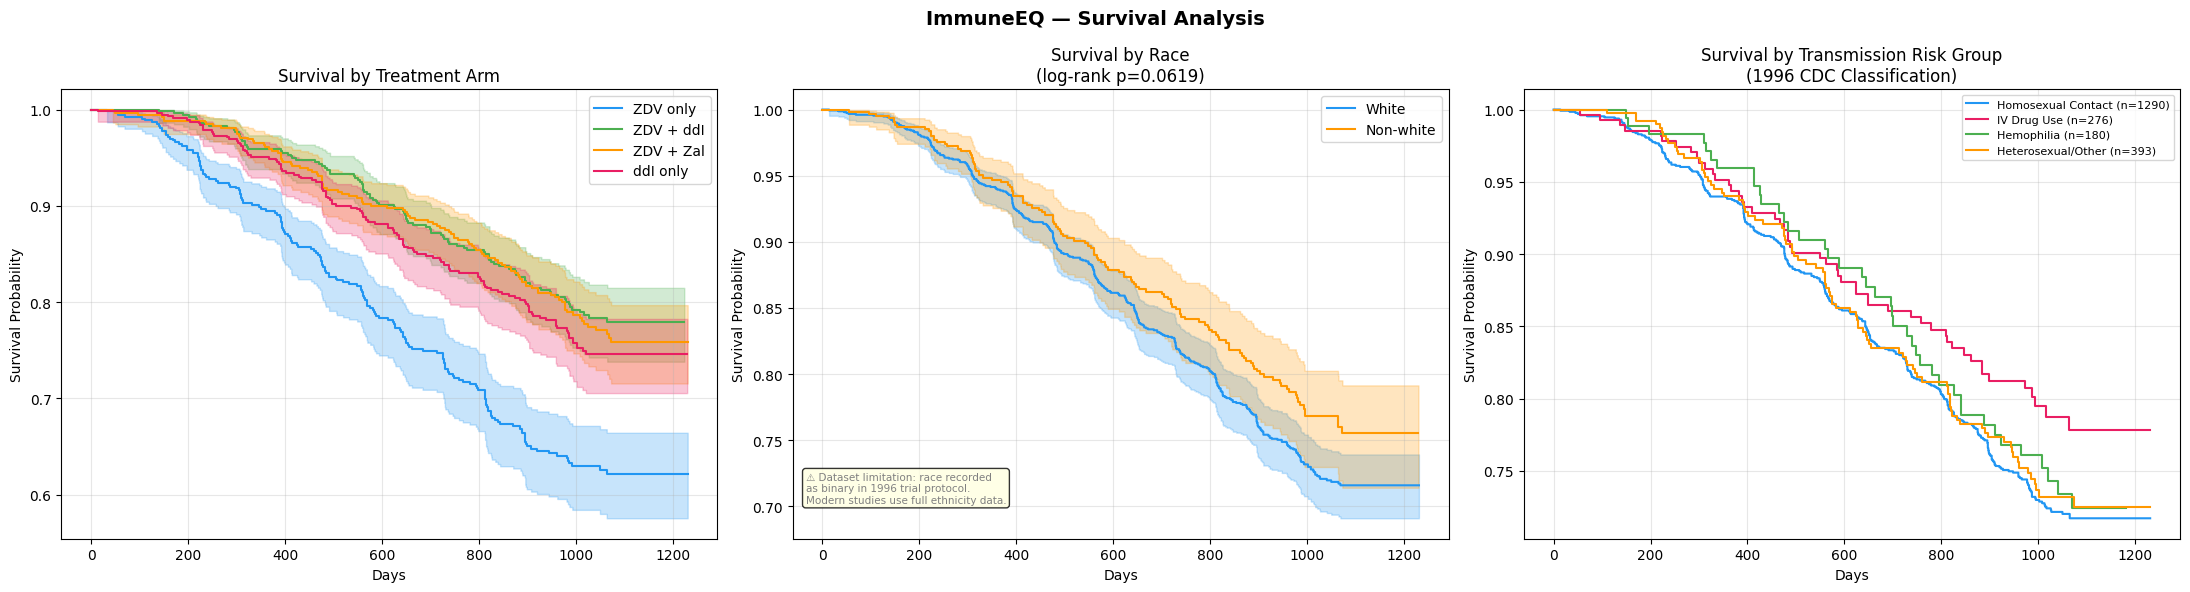


Risk group breakdown:
risk_group
Homosexual Contact    1290
Heterosexual/Other     393
IV Drug Use            276
Hemophilia             180
Name: count, dtype: int64


In [17]:
!pip install lifelines -q
# Step 9: Kaplan-Meier Survival Analysis
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('ImmuneEQ — Survival Analysis', fontsize=14, fontweight='bold')

# ── Plot 1: Survival by Treatment Arm ─────────────────────────────────────────
ax = axes[0]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
trt_labels = {0: 'ZDV only', 1: 'ZDV + ddI', 2: 'ZDV + Zal', 3: 'ddI only'}

for trt_val, color in zip([0, 1, 2, 3], colors):
    mask = df['trt'] == trt_val
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, 'time'], event_observed=df.loc[mask, 'cid'],
            label=trt_labels[trt_val])
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

ax.set_title('Survival by Treatment Arm')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.grid(alpha=0.3)
ax.legend()

# ── Plot 2: Survival by Race (with dataset limitation note) ───────────────────
ax = axes[1]
for race_val, label, color in [(0, 'White', '#2196F3'), (1, 'Non-white', '#FF9800')]:
    mask = df['race'] == race_val
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, 'time'], event_observed=df.loc[mask, 'cid'], label=label)
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

w = df['race'] == 0
results = logrank_test(df.loc[w, 'time'], df.loc[~w, 'time'],
                       event_observed_A=df.loc[w, 'cid'],
                       event_observed_B=df.loc[~w, 'cid'])
ax.set_title(f'Survival by Race\n(log-rank p={results.p_value:.4f})')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.grid(alpha=0.3)
ax.legend()
ax.annotate('⚠ Dataset limitation: race recorded\nas binary in 1996 trial protocol.\nModern studies use full ethnicity data.',
            xy=(0.02, 0.08), xycoords='axes fraction',
            fontsize=7.5, color='gray',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ── Plot 3: Survival by Transmission Risk Group ───────────────────────────────
ax = axes[2]

# Build risk group labels from available binary columns
def get_risk_group(row):
    if row['hemo'] == 1:
        return 'Hemophilia'
    elif row['drugs'] == 1:
        return 'IV Drug Use'
    elif row['homo'] == 1:
        return 'Homosexual Contact'
    else:
        return 'Heterosexual/Other'

df['risk_group'] = df.apply(get_risk_group, axis=1)

risk_colors = {
    'Homosexual Contact': '#2196F3',
    'IV Drug Use':        '#E91E63',
    'Hemophilia':         '#4CAF50',
    'Heterosexual/Other': '#FF9800'
}

for group, color in risk_colors.items():
    mask = df['risk_group'] == group
    if mask.sum() < 10:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, 'time'], event_observed=df.loc[mask, 'cid'],
            label=f'{group} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, color=color, ci_show=False)

ax.set_title('Survival by Transmission Risk Group\n(1996 CDC Classification)')
ax.set_xlabel('Days')
ax.set_ylabel('Survival Probability')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('08_survival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print group sizes
print("\nRisk group breakdown:")
print(df['risk_group'].value_counts())